In [ ]:

import os
import re
import glob
import json
import math
import random
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from skimage.filters import gabor_kernel
from scipy import ndimage as ndi
from scipy.spatial.distance import mahalanobis

random.seed(42)
np.random.seed(42)

INPUT_ROOT = "/kaggle/input"
OUTPUT_ROOT = "/kaggle/working"
os.makedirs(OUTPUT_ROOT, exist_ok=True)

# Auto-discover the AITEX dataset folder under /kaggle/input
candidate_roots = [d for d in glob.glob(os.path.join(INPUT_ROOT, "*")) if os.path.isdir(d)]
print("Datasets available under /kaggle/input:")
for c in candidate_roots:
    print(" -", c)

# >>> SET THIS after inspecting the printed list above <<<
DATASET_ROOT = candidate_roots[0] if candidate_roots else None
print("\nUsing DATASET_ROOT =", DATASET_ROOT)

# Walk the tree and bucket files by extension / folder name keywords
all_images = glob.glob(os.path.join(DATASET_ROOT, "**", "*.*"), recursive=True)
all_images = [f for f in all_images if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"))]
print(f"\nTotal image files found: {len(all_images)}")

def classify_path(p):
    lp = p.lower()
    if "mask" in lp:
        return "mask"
    if "nodefect" in lp or "no_defect" in lp or "good" in lp:
        return "normal"
    if "defect" in lp:
        return "defect"
    return "unknown"

buckets = defaultdict(list)
for f in all_images:
    buckets[classify_path(f)].append(f)

for k, v in buckets.items():
    print(f"{k}: {len(v)} files")

# Save raw file lists to working dir for later cells / reproducibility
with open(os.path.join(OUTPUT_ROOT, "file_buckets.json"), "w") as fh:
    json.dump({k: sorted(v) for k, v in buckets.items()}, fh, indent=2)



def parse_defect_filename(fname):
    """Best-effort parser for AITEX defective-image filenames."""
    stem = os.path.splitext(os.path.basename(fname))[0]
    parts = re.split(r"[_\-]", stem)
    fabric_id = parts[0] if len(parts) > 0 else "unknown"
    defect_code = parts[-1] if len(parts) > 2 else "unknown"
    return fabric_id, defect_code

defect_records = []
for f in buckets["defect"]:
    fabric_id, defect_code = parse_defect_filename(f)
    defect_records.append({"path": f, "fabric_id": fabric_id, "defect_code": defect_code})

df_defects = pd.DataFrame(defect_records)
print("Defect image count by fabric_id:")
print(df_defects["fabric_id"].value_counts())
print("\nDefect image count by defect_code (raw parse — verify against AITEX docs):")
print(df_defects["defect_code"].value_counts())

normal_records = []
for f in buckets["normal"]:
    fabric_id, _ = parse_defect_filename(f)
    normal_records.append({"path": f, "fabric_id": fabric_id})
df_normal = pd.DataFrame(normal_records)
print("\nDefect-free image count by fabric_id:")
print(df_normal["fabric_id"].value_counts())

# Match defective images to masks by stem similarity
mask_lookup = {os.path.splitext(os.path.basename(m))[0]: m for m in buckets["mask"]}

def find_mask_for(defect_path):
    stem = os.path.splitext(os.path.basename(defect_path))[0]
    if stem in mask_lookup:
        return mask_lookup[stem]
    # try stripping/adding common suffixes
    for suffix in ["_mask", "-mask", "_gt"]:
        alt = stem + suffix
        if alt in mask_lookup:
            return mask_lookup[alt]
    base = stem.replace("_mask", "").replace("-mask", "")
    if base in mask_lookup:
        return mask_lookup[base]
    return None

df_defects["mask_path"] = df_defects["path"].apply(find_mask_for)
n_matched = df_defects["mask_path"].notna().sum()
print(f"\nMatched masks: {n_matched}/{len(df_defects)}")
if n_matched < len(df_defects):
    print("WARNING: some defective images have no matched mask — inspect naming convention manually:")
    print(df_defects[df_defects["mask_path"].isna()]["path"].head(10).tolist())

df_defects.to_csv(os.path.join(OUTPUT_ROOT, "defect_index.csv"), index=False)
df_normal.to_csv(os.path.join(OUTPUT_ROOT, "normal_index.csv"), index=False)



def img_props(path):
    im = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if im is None:
        return None
    shape = im.shape
    return {"path": path, "h": shape[0], "w": shape[1],
            "channels": shape[2] if len(shape) == 3 else 1, "dtype": str(im.dtype)}

sample_paths = random.sample(all_images, min(30, len(all_images)))
props = [p for p in (img_props(f) for f in sample_paths) if p is not None]
df_props = pd.DataFrame(props)
print(df_props[["h", "w", "channels", "dtype"]].describe(include="all"))


def load_gray(path):
    im = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    return im

fabric_ids = df_normal["fabric_id"].unique()[:7]
fig, axes = plt.subplots(1, len(fabric_ids), figsize=(4 * len(fabric_ids), 4))
if len(fabric_ids) == 1:
    axes = [axes]
for ax, fid in zip(axes, fabric_ids):
    sample = df_normal[df_normal["fabric_id"] == fid]["path"].iloc[0]
    im = load_gray(sample)
    ax.imshow(im, cmap="gray")
    ax.set_title(f"Fabric {fid}")
    ax.axis("off")
plt.suptitle("Defect-free texture samples per fabric type")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_ROOT, "eda_fabric_types.png"), dpi=120)
plt.show()



def overlay_mask(img_path, mask_path, alpha=0.4):
    im = load_gray(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (im.shape[1], im.shape[0]))
    im_rgb = cv2.cvtColor(im, cv2.COLOR_GRAY2RGB)
    overlay = im_rgb.copy()
    overlay[mask > 0] = [255, 0, 0]
    blended = cv2.addWeighted(overlay, alpha, im_rgb, 1 - alpha, 0)
    return blended, mask

matched = df_defects.dropna(subset=["mask_path"])
sample_defects = matched.sample(min(6, len(matched)), random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (_, row) in zip(axes.flat, sample_defects.iterrows()):
    blended, mask = overlay_mask(row["path"], row["mask_path"])
    ax.imshow(blended)
    ax.set_title(f"fabric={row['fabric_id']} defect={row['defect_code']}")
    ax.axis("off")
plt.suptitle("Ground-truth defect masks overlaid on defective images")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_ROOT, "eda_mask_overlays.png"), dpi=120)
plt.show()


size_records = []
for _, row in matched.iterrows():
    mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
    if mask is None:
        continue
    area_px = int((mask > 0).sum())
    pct = 100.0 * area_px / mask.size
    size_records.append({"defect_code": row["defect_code"], "area_px": area_px, "area_pct": pct})

df_sizes = pd.DataFrame(size_records)
print(df_sizes.groupby("defect_code")["area_pct"].describe())

plt.figure(figsize=(10, 5))
df_sizes.boxplot(column="area_pct", by="defect_code", rot=90)
plt.ylabel("Defect area (% of image)")
plt.title("Defect size distribution by defect type")
plt.suptitle("")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_ROOT, "eda_defect_sizes.png"), dpi=120)
plt.show()


brightness_records = []
for f in random.sample(all_images, min(200, len(all_images))):
    im = load_gray(f)
    if im is None:
        continue
    brightness_records.append({"path": f, "mean": im.mean(), "std": im.std(),
                                "bucket": classify_path(f)})
df_bright = pd.DataFrame(brightness_records)
plt.figure(figsize=(8, 5))
for b in df_bright["bucket"].unique():
    plt.hist(df_bright[df_bright["bucket"] == b]["mean"], bins=20, alpha=0.5, label=b)
plt.xlabel("Mean pixel intensity")
plt.ylabel("Count")
plt.legend()
plt.title("Illumination variation across images")
plt.savefig(os.path.join(OUTPUT_ROOT, "eda_illumination.png"), dpi=120)
plt.show()


clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def preprocess_image(path, denoise=True):
    im = load_gray(path)
    if im is None:
        return None
    im = clahe.apply(im)
    if denoise:
        im = cv2.GaussianBlur(im, (3, 3), 0)
    return im

sample = df_normal["path"].iloc[0]
raw = load_gray(sample)
proc = preprocess_image(sample)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(raw, cmap="gray"); ax[0].set_title("Raw"); ax[0].axis("off")
ax[1].imshow(proc, cmap="gray"); ax[1].set_title("CLAHE + mild blur"); ax[1].axis("off")
plt.savefig(os.path.join(OUTPUT_ROOT, "preprocess_before_after.png"), dpi=120)
plt.show()

PATCH_SIZE = 64      # tune based on defect-size EDA (Cell 5) — smallest defects should still
STRIDE = 32           # roughly fill a patch; halve stride vs patch size for overlap
DEFECT_OVERLAP_THRESH = 0.10   # patch labeled "defect" if >=10% of its pixels are masked

def extract_patches(img, mask=None, patch_size=PATCH_SIZE, stride=STRIDE):
    """Yields (patch, label, (y, x)) — label is 1 if mask overlap exceeds threshold, else 0.
    If mask is None, all labels are 0 (used for defect-free images)."""
    h, w = img.shape
    results = []
    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            patch = img[y:y + patch_size, x:x + patch_size]
            label = 0
            if mask is not None:
                m_patch = mask[y:y + patch_size, x:x + patch_size]
                overlap = (m_patch > 0).mean()
                label = int(overlap >= DEFECT_OVERLAP_THRESH)
            results.append((patch, label, (y, x)))
    return results

# Build a manageable patch dataset: cap number of source images per class to keep Week-2 runtime sane
MAX_NORMAL_IMAGES = 40
MAX_DEFECT_IMAGES = 40

normal_sample = df_normal.sample(min(MAX_NORMAL_IMAGES, len(df_normal)), random_state=42)
defect_sample = matched.sample(min(MAX_DEFECT_IMAGES, len(matched)), random_state=42)

patch_records = []  # (patch_array will be stored separately to keep the index lightweight)
patch_arrays = []
patch_labels = []
patch_fabric = []
patch_source = []

for _, row in normal_sample.iterrows():
    im = preprocess_image(row["path"])
    if im is None:
        continue
    for patch, label, (y, x) in extract_patches(im, mask=None):
        patch_arrays.append(patch)
        patch_labels.append(0)
        patch_fabric.append(row["fabric_id"])
        patch_source.append(row["path"])

for _, row in defect_sample.iterrows():
    im = preprocess_image(row["path"])
    mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
    if im is None or mask is None:
        continue
    if mask.shape != im.shape:
        mask = cv2.resize(mask, (im.shape[1], im.shape[0]))
    for patch, label, (y, x) in extract_patches(im, mask=mask):
        patch_arrays.append(patch)
        patch_labels.append(label)
        patch_fabric.append(row["fabric_id"])
        patch_source.append(row["path"])

patch_labels = np.array(patch_labels)
print(f"Total patches: {len(patch_arrays)}")
print(f"Normal patches: {(patch_labels == 0).sum()}  |  Defective patches: {(patch_labels == 1).sum()}")

np.save(os.path.join(OUTPUT_ROOT, "patch_labels.npy"), patch_labels)


# %% [CELL 9] — Texture descriptors: GLCM
GLCM_DISTANCES = [1, 3]
GLCM_ANGLES = [0, np.pi/4, np.pi/2, 3*np.pi/4]
GLCM_PROPS = ["contrast", "correlation", "energy", "homogeneity"]

def glcm_features(patch, levels=32):
    """Quantize to `levels` gray levels to keep GLCM computation cheap, then extract stats."""
    q = (patch.astype(np.float32) / 256.0 * levels).astype(np.uint8)
    q = np.clip(q, 0, levels - 1)
    glcm = graycomatrix(q, distances=GLCM_DISTANCES, angles=GLCM_ANGLES,
                         levels=levels, symmetric=True, normed=True)
    feats = []
    for prop in GLCM_PROPS:
        vals = graycoprops(glcm, prop)  # shape (n_distances, n_angles)
        feats.extend(vals.mean(axis=1))       # mean over angles, per distance -> rotation-robust
        feats.extend(vals.std(axis=1))        # std over angles -> anisotropy indicator
    return np.array(feats)

# quick unit test
test_feat = glcm_features(patch_arrays[0])
print("GLCM feature vector length:", test_feat.shape, test_feat[:5])



LBP_CONFIGS = [(8, 1), (16, 2)]  # (P, R) pairs

def lbp_features(patch):
    feats = []
    for P, R in LBP_CONFIGS:
        lbp = local_binary_pattern(patch, P, R, method="uniform")
        n_bins = P + 2
        hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)
        feats.extend(hist)
    return np.array(feats)

test_feat = lbp_features(patch_arrays[0])
print("LBP feature vector length:", test_feat.shape)


GABOR_FREQS = [0.1, 0.3]
GABOR_THETAS = [0, np.pi/4, np.pi/2, 3*np.pi/4]

_gabor_kernels = [gabor_kernel(freq, theta=theta).real
                   for freq in GABOR_FREQS for theta in GABOR_THETAS]

def gabor_features(patch):
    patch_f = patch.astype(np.float32) / 255.0
    feats = []
    for kernel in _gabor_kernels:
        filtered = ndi.convolve(patch_f, kernel, mode="wrap")
        feats.append(filtered.mean())
        feats.append(filtered.var())
    return np.array(feats)

test_feat = gabor_features(patch_arrays[0])
print("Gabor feature vector length:", test_feat.shape)



def fft_features(patch):
    f = np.fft.fftshift(np.fft.fft2(patch.astype(np.float32)))
    mag = np.log1p(np.abs(f))
    h, w = mag.shape
    cy, cx = h // 2, w // 2
    # radial energy in a few concentric bands (crude but effective + cheap)
    yy, xx = np.mgrid[0:h, 0:w]
    r = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)
    bands = [(0, 4), (4, 10), (10, 20), (20, max(h, w))]
    feats = []
    for lo, hi in bands:
        band_mask = (r >= lo) & (r < hi)
        feats.append(mag[band_mask].mean() if band_mask.any() else 0.0)
        feats.append(mag[band_mask].std() if band_mask.any() else 0.0)
    return np.array(feats)

test_feat = fft_features(patch_arrays[0])
print("FFT feature vector length:", test_feat.shape)

def combined_features(patch):
    return np.concatenate([
        glcm_features(patch),
        lbp_features(patch),
        gabor_features(patch),
        fft_features(patch),
    ])

print("Extracting combined features for all patches...")
feature_matrix = np.array([combined_features(p) for p in patch_arrays])
print("Feature matrix shape:", feature_matrix.shape)

np.save(os.path.join(OUTPUT_ROOT, "feature_matrix.npy"), feature_matrix)



patch_fabric = np.array(patch_fabric)
fabric_models = {}  # fabric_id -> (mean_vec, inv_cov)

for fid in np.unique(patch_fabric):
    normal_idx = (patch_fabric == fid) & (patch_labels == 0)
    X_normal = feature_matrix[normal_idx]
    if len(X_normal) < feature_matrix.shape[1] + 5:
        print(f"Fabric {fid}: not enough normal patches ({len(X_normal)}) for stable covariance — skipping")
        continue
    mean_vec = X_normal.mean(axis=0)
    cov = np.cov(X_normal, rowvar=False)
    cov += np.eye(cov.shape[0]) * 1e-6  # regularize for invertibility
    inv_cov = np.linalg.pinv(cov)
    fabric_models[fid] = (mean_vec, inv_cov)

print("Fabric-specific normal-texture models built for:", list(fabric_models.keys()))

def anomaly_score(feat_vec, fabric_id):
    if fabric_id not in fabric_models:
        return np.nan
    mean_vec, inv_cov = fabric_models[fabric_id]
    return mahalanobis(feat_vec, mean_vec, inv_cov)

scores = np.array([anomaly_score(feature_matrix[i], patch_fabric[i]) for i in range(len(patch_arrays))])
np.save(os.path.join(OUTPUT_ROOT, "anomaly_scores.npy"), scores)



valid = ~np.isnan(scores)
df_scores = pd.DataFrame({"score": scores[valid], "label": patch_labels[valid]})

plt.figure(figsize=(6, 5))
df_scores.boxplot(column="score", by="label")
plt.xlabel("Label (0=normal, 1=defect)")
plt.ylabel("Mahalanobis anomaly score")
plt.title("Anomaly score separability: normal vs. defective patches")
plt.suptitle("")
plt.savefig(os.path.join(OUTPUT_ROOT, "score_separability.png"), dpi=120)
plt.show()

print(df_scores.groupby("label")["score"].describe())

# Quick separability metric: AUC-like rank statistic without extra deps
from itertools import product
normal_scores = df_scores[df_scores.label == 0]["score"].values
defect_scores = df_scores[df_scores.label == 1]["score"].values
if len(normal_scores) and len(defect_scores):
    wins = np.mean([d > n for n, d in
                     zip(np.random.choice(normal_scores, 2000), np.random.choice(defect_scores, 2000))])
    print(f"Approx. probability a random defect patch outscores a random normal patch: {wins:.3f}")

def compute_iou(pred_mask, gt_mask):
    pred_bin = pred_mask > 0
    gt_bin = gt_mask > 0
    intersection = np.logical_and(pred_bin, gt_bin).sum()
    union = np.logical_or(pred_bin, gt_bin).sum()
    return intersection / union if union > 0 else np.nan

def compute_precision_recall(pred_mask, gt_mask):
    pred_bin = pred_mask > 0
    gt_bin = gt_mask > 0
    tp = np.logical_and(pred_bin, gt_bin).sum()
    fp = np.logical_and(pred_bin, ~gt_bin).sum()
    fn = np.logical_and(~pred_bin, gt_bin).sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    return precision, recall

def build_score_heatmap(img_path, fabric_id, patch_size=PATCH_SIZE, stride=STRIDE):
    """Slide over a full image, score each patch, and paint a heatmap for visualization."""
    im = preprocess_image(img_path)
    h, w = im.shape
    heat = np.zeros((h, w), dtype=np.float32)
    count = np.zeros((h, w), dtype=np.float32)
    for patch, _, (y, x) in extract_patches(im, mask=None, patch_size=patch_size, stride=stride):
        feat = combined_features(patch)
        s = anomaly_score(feat, fabric_id)
        heat[y:y+patch_size, x:x+patch_size] += (0 if np.isnan(s) else s)
        count[y:y+patch_size, x:x+patch_size] += 1
    count[count == 0] = 1
    return heat / count

# Demo on one defective image with a known fabric model
demo_row = None
for _, row in defect_sample.iterrows():
    if row["fabric_id"] in fabric_models:
        demo_row = row
        break

if demo_row is not None:
    heat = build_score_heatmap(demo_row["path"], demo_row["fabric_id"])
    gt_mask = cv2.imread(demo_row["mask_path"], cv2.IMREAD_GRAYSCALE)
    gt_mask = cv2.resize(gt_mask, (heat.shape[1], heat.shape[0]))

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(load_gray(demo_row["path"]), cmap="gray"); ax[0].set_title("Original"); ax[0].axis("off")
    ax[1].imshow(heat, cmap="hot"); ax[1].set_title("Anomaly score heatmap"); ax[1].axis("off")
    ax[2].imshow(gt_mask, cmap="gray"); ax[2].set_title("Ground-truth mask"); ax[2].axis("off")
    plt.savefig(os.path.join(OUTPUT_ROOT, "heatmap_demo.png"), dpi=120)
    plt.show()
else:
    print("No defective sample with a fitted fabric model was found for the heatmap demo — "
          "increase MAX_DEFECT_IMAGES / MAX_NORMAL_IMAGES in Cell 8 and re-run.")


summary = {
    "total_images_found": len(all_images),
    "normal_images": len(df_normal),
    "defect_images": len(df_defects),
    "masks_matched": int(n_matched),
    "fabric_types_seen": sorted(df_normal["fabric_id"].unique().tolist()),
    "defect_types_seen": sorted(df_defects["defect_code"].unique().tolist()),
    "total_patches_extracted": len(patch_arrays),
    "normal_patches": int((patch_labels == 0).sum()),
    "defect_patches": int((patch_labels == 1).sum()),
    "feature_vector_length": int(feature_matrix.shape[1]),
    "fabric_models_built": list(fabric_models.keys()),
}
with open(os.path.join(OUTPUT_ROOT, "week2_checkpoint_summary.json"), "w") as fh:
    json.dump(summary, fh, indent=2)

print(json.dumps(summary, indent=2))

In [ ]:

import os
import re
import glob
import random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern

RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.grid"] = False



def find_afid_root(search_roots=("/kaggle/input", ".", "..")):
    """
    Walks the given search roots looking for a directory that contains
    NODefect_images, Defect_images, and Mask_images (or close variants).
    Returns the parent directory that holds all three.
    """
    targets = {"nodefect_images", "defect_images", "mask_images"}
    for root in search_roots:
        if not os.path.isdir(root):
            continue
        for dirpath, dirnames, _ in os.walk(root):
            lower_dirs = {d.lower() for d in dirnames}
            if targets.issubset(lower_dirs):
                return dirpath
    raise FileNotFoundError(
        "Could not auto-locate NODefect_images / Defect_images / Mask_images. "
        "Check the Kaggle 'Add Data' panel for the exact dataset path and set "
        "AFID_ROOT manually below."
    )


try:
    AFID_ROOT = find_afid_root()
except FileNotFoundError:
    AFID_ROOT = "/kaggle/input/aitex-afid"  # <-- EDIT if auto-discovery fails

print(f"AFID root: {AFID_ROOT}")

# Resolve the three subfolders case-insensitively
def resolve_subdir(root, name):
    for d in os.listdir(root):
        if d.lower() == name.lower():
            return os.path.join(root, d)
    raise FileNotFoundError(f"'{name}' not found under {root}")

NODEFECT_DIR = resolve_subdir(AFID_ROOT, "NODefect_images")
DEFECT_DIR = resolve_subdir(AFID_ROOT, "Defect_images")
MASK_DIR = resolve_subdir(AFID_ROOT, "Mask_images")

print("NODefect_images :", NODEFECT_DIR)
print("Defect_images   :", DEFECT_DIR)
print("Mask_images     :", MASK_DIR)


IMG_EXTS = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

def list_images(folder):
    files = []
    for dirpath, _, filenames in os.walk(folder):
        for f in filenames:
            if f.lower().endswith(IMG_EXTS):
                files.append(os.path.join(dirpath, f))
    return sorted(files)

nodefect_files = list_images(NODEFECT_DIR)
defect_files = list_images(DEFECT_DIR)
mask_files = list_images(MASK_DIR)

print(f"Defect-free images : {len(nodefect_files)}")
print(f"Defective images   : {len(defect_files)}")
print(f"Mask images        : {len(mask_files)}")


DEFECT_NAME_RE = re.compile(
    r"^(?P<fabric>\d{4})_(?P<roll>\d+)_(?P<idx>\d+)_?(?P<defect>[a-zA-Z_\-]*)\.\w+$"
)

def parse_defect_filename(path):
    stem = os.path.basename(path)
    m = DEFECT_NAME_RE.match(stem)
    if m:
        fabric = m.group("fabric")
        defect = m.group("defect").strip("_") or "unknown"
    else:
        # Fallback: fabric = first 4 chars, defect = tokens after 3rd underscore
        parts = re.split(r"[_\.]", stem)
        fabric = parts[0] if parts else "unknown"
        defect = "_".join(parts[3:-1]) if len(parts) > 4 else "unknown"
    return fabric, defect

def parse_nodefect_filename(path):
    stem = os.path.basename(path)
    parts = re.split(r"[_\.]", stem)
    fabric = parts[0] if parts else "unknown"
    return fabric

records = []
for f in nodefect_files:
    fabric = parse_nodefect_filename(f)
    records.append({"path": f, "label": "defect_free", "fabric_type": fabric,
                     "defect_type": "none"})

for f in defect_files:
    fabric, defect = parse_defect_filename(f)
    # Try to find a matching mask by shared filename stem
    stem = os.path.splitext(os.path.basename(f))[0]
    match = next((m for m in mask_files if stem in os.path.basename(m)), None)
    records.append({"path": f, "label": "defective", "fabric_type": fabric,
                     "defect_type": defect, "mask_path": match})

df = pd.DataFrame(records)
df["mask_path"] = df.get("mask_path", pd.Series(dtype=object))
print(df.head())
print(df.shape)


# %% [4] Dataset composition: counts & tables ---------------------------------
print("\n--- Class balance ---")
print(df["label"].value_counts())

print("\n--- Images per fabric type ---")
print(df["fabric_type"].value_counts().sort_index())

print("\n--- Defect type distribution (defective only) ---")
defect_counts = df.loc[df["label"] == "defective", "defect_type"].value_counts()
print(defect_counts)

matched_masks = df.loc[df["label"] == "defective", "mask_path"].notna().sum()
print(f"\nDefective images with a matched mask: {matched_masks}/{(df['label']=='defective').sum()}")


# %% [5] Plot: class balance + fabric-type distribution -----------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df["label"].value_counts().plot(
    kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Defect-free vs Defective image counts")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of images")
axes[0].tick_params(axis="x", rotation=0)

fabric_counts = df["fabric_type"].value_counts().sort_index()
fabric_counts.plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Images per fabric type")
axes[1].set_xlabel("Fabric type code")
axes[1].set_ylabel("Number of images")
plt.tight_layout()
plt.savefig("class_and_fabric_distribution.png", dpi=150)
plt.show()


# %% [6] Plot: defect-type distribution (the 12 defect classes) --------------
plt.figure(figsize=(11, 5))
defect_counts.sort_values(ascending=False).plot(kind="bar", color="#C44E52")
plt.title("Defect type distribution across AFID")
plt.xlabel("Defect type")
plt.ylabel("Number of images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("defect_type_distribution.png", dpi=150)
plt.show()


# %% [7] Sample grid: defect-free patches across fabric types ----------------
def show_image_grid(paths, titles, ncols=4, cmap="gray", figsize=None, suptitle=None):
    n = len(paths)
    nrows = int(np.ceil(n / ncols))
    figsize = figsize or (4 * ncols, 3 * nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)
    for ax, p, t in zip(axes, paths, titles):
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        ax.imshow(img, cmap=cmap)
        ax.set_title(t, fontsize=9)
        ax.axis("off")
    for ax in axes[len(paths):]:
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=13)
    plt.tight_layout()
    return fig

sample_free = (df[df["label"] == "defect_free"]
               .groupby("fabric_type").first().reset_index())
fig = show_image_grid(
    sample_free["path"].tolist(),
    [f"Fabric {ft}" for ft in sample_free["fabric_type"]],
    ncols=4, suptitle="One defect-free sample per fabric type")
plt.savefig("defect_free_samples_per_fabric.png", dpi=150)
plt.show()


sample_defect = (df[df["label"] == "defective"]
                  .groupby("defect_type").first().reset_index())
fig = show_image_grid(
    sample_defect["path"].tolist(),
    [f"{dt}" for dt in sample_defect["defect_type"]],
    ncols=4, suptitle="One defective sample per defect type")
plt.savefig("defective_samples_per_defect_type.png", dpi=150)
plt.show()


def overlay_mask(img, mask, color=(255, 0, 0), alpha=0.45):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB).astype(np.float32)
    mask_bool = mask > 0
    overlay = img_rgb.copy()
    overlay[mask_bool] = (
        (1 - alpha) * img_rgb[mask_bool] + alpha * np.array(color)
    )
    return overlay.astype(np.uint8)

matched = df[(df["label"] == "defective") & (df["mask_path"].notna())]
n_show = min(6, len(matched))
sample_matched = matched.sample(n_show, random_state=RNG_SEED)

fig, axes = plt.subplots(n_show, 3, figsize=(12, 3 * n_show))
if n_show == 1:
    axes = axes.reshape(1, -1)

for row_i, (_, row) in enumerate(sample_matched.iterrows()):
    img = cv2.imread(row["path"], cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
    if mask.shape != img.shape:
        mask = cv2.resize(mask, (img.shape[1], img.shape[0]),
                           interpolation=cv2.INTER_NEAREST)
    overlay = overlay_mask(img, mask)

    axes[row_i, 0].imshow(img, cmap="gray")
    axes[row_i, 0].set_title(f"Image ({row['defect_type']})", fontsize=9)
    axes[row_i, 1].imshow(mask, cmap="gray")
    axes[row_i, 1].set_title("Ground-truth mask", fontsize=9)
    axes[row_i, 2].imshow(overlay)
    axes[row_i, 2].set_title("Overlay", fontsize=9)
    for c in range(3):
        axes[row_i, c].axis("off")

plt.tight_layout()
plt.savefig("defect_mask_overlays.png", dpi=150)
plt.show()


# %% [10] Image dimension / aspect-ratio audit --------------------------------
dims = []
for p in df["path"].sample(min(300, len(df)), random_state=RNG_SEED):
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    dims.append(img.shape)

dims_df = pd.DataFrame(dims, columns=["height", "width"])
print("\n--- Image dimensions (sampled) ---")
print(dims_df.describe())
print("Unique (h, w) pairs:", dims_df.drop_duplicates().values.tolist())


# %% [11] Pixel-intensity distribution: defect-free vs defective -------------
def mean_hist(paths, bins=256):
    hist_sum = np.zeros(bins)
    for p in paths:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        h, _ = np.histogram(img, bins=bins, range=(0, 255))
        hist_sum += h
    return hist_sum / len(paths)

free_sample = df[df["label"] == "defect_free"]["path"].sample(
    min(150, (df["label"] == "defect_free").sum()), random_state=RNG_SEED)
defect_sample = df[df["label"] == "defective"]["path"].sample(
    min(150, (df["label"] == "defective").sum()), random_state=RNG_SEED)

hist_free = mean_hist(free_sample)
hist_defect = mean_hist(defect_sample)

plt.figure(figsize=(9, 5))
plt.plot(hist_free, label="Defect-free (avg.)", color="#4C72B0")
plt.plot(hist_defect, label="Defective (avg.)", color="#DD8452")
plt.title("Average grayscale intensity histogram")
plt.xlabel("Pixel intensity")
plt.ylabel("Mean count")
plt.legend()
plt.tight_layout()
plt.savefig("intensity_histograms.png", dpi=150)
plt.show()


# %% [12] Texture preview: GLCM + LBP on a defect-free vs defective patch ----
def glcm_features(img, distances=(1, 3, 5), angles=(0, np.pi/4, np.pi/2, 3*np.pi/4)):
    glcm = graycomatrix(img, distances=list(distances), angles=list(angles),
                         levels=256, symmetric=True, normed=True)
    feats = {}
    for prop in ("contrast", "homogeneity", "energy", "correlation", "dissimilarity", "ASM"):
        feats[prop] = graycoprops(glcm, prop).mean()
    return feats

def lbp_image(img, P=8, R=1):
    return local_binary_pattern(img, P=P, R=R, method="uniform")

example_free_path = df[df["label"] == "defect_free"]["path"].iloc[0]
example_defect_row = matched.iloc[0]

img_free = cv2.imread(example_free_path, cv2.IMREAD_GRAYSCALE)
img_defect = cv2.imread(example_defect_row["path"], cv2.IMREAD_GRAYSCALE)
mask_defect = cv2.imread(example_defect_row["mask_path"], cv2.IMREAD_GRAYSCALE)

lbp_free = lbp_image(img_free)
lbp_defect = lbp_image(img_defect)

feats_free = glcm_features(img_free)
feats_defect = glcm_features(img_defect)

print("\n--- GLCM features: defect-free patch ---")
for k, v in feats_free.items():
    print(f"  {k:14s}: {v:.4f}")
print("--- GLCM features: defective patch ---")
for k, v in feats_defect.items():
    print(f"  {k:14s}: {v:.4f}")

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes[0, 0].imshow(img_free, cmap="gray"); axes[0, 0].set_title("Defect-free: raw")
axes[0, 1].imshow(lbp_free, cmap="gray"); axes[0, 1].set_title("Defect-free: LBP map")
axes[0, 2].hist(lbp_free.ravel(), bins=59, color="#4C72B0")
axes[0, 2].set_title("Defect-free: LBP histogram")

axes[1, 0].imshow(img_defect, cmap="gray"); axes[1, 0].set_title(f"Defective ({example_defect_row['defect_type']}): raw")
axes[1, 1].imshow(lbp_defect, cmap="gray"); axes[1, 1].set_title("Defective: LBP map")
axes[1, 2].hist(lbp_defect.ravel(), bins=59, color="#DD8452")
axes[1, 2].set_title("Defective: LBP histogram")

for ax in axes[:, :2].ravel():
    ax.axis("off")
plt.tight_layout()
plt.savefig("texture_preview_glcm_lbp.png", dpi=150)
plt.show()


# %% [13] Save the manifest for downstream use --------------------------------
df.to_csv("afid_manifest.csv", index=False)
print("\nSaved manifest to afid_manifest.csv")
print("Saved figures: class_and_fabric_distribution.png, defect_type_distribution.png, "
      "defect_free_samples_per_fabric.png, defective_samples_per_defect_type.png, "
      "defect_mask_overlays.png, intensity_histograms.png, texture_preview_glcm_lbp.png")

In [ ]:

from joblib import Parallel, delayed
from tqdm import tqdm

np.random.seed(42)

MAX_NORMAL_PATCHES_PER_FABRIC = 400   # caps training set size per fabric type
MAX_NORMAL_EVAL_PATCHES = 3000        # normal patches sampled for evaluation only

patch_labels = np.array(patch_labels)
patch_fabric = np.array(patch_fabric)
n_total_patches = len(patch_arrays)

# --- Training index: capped normal patches per fabric type ---
train_idx = []
for fid in np.unique(patch_fabric):
    fid_normal_idx = np.where((patch_fabric == fid) & (patch_labels == 0))[0]
    if len(fid_normal_idx) > MAX_NORMAL_PATCHES_PER_FABRIC:
        fid_normal_idx = np.random.choice(
            fid_normal_idx, MAX_NORMAL_PATCHES_PER_FABRIC, replace=False)
    train_idx.extend(fid_normal_idx.tolist())
train_idx = np.array(sorted(set(train_idx)))

# --- Evaluation index: ALL defective patches + a sample of normal patches ---
defect_idx = np.where(patch_labels == 1)[0]
normal_all_idx = np.where(patch_labels == 0)[0]
eval_normal_idx = np.random.choice(
    normal_all_idx, min(MAX_NORMAL_EVAL_PATCHES, len(normal_all_idx)), replace=False)
eval_idx = np.array(sorted(set(defect_idx.tolist()) | set(eval_normal_idx.tolist())))

# --- Combined set of patches we actually need features for ---
feature_idx = np.array(sorted(set(train_idx.tolist()) | set(eval_idx.tolist())))
print(f"Total patches available: {n_total_patches}")
print(f"Training patches (normal, capped per fabric): {len(train_idx)}")
print(f"Evaluation patches (all defective + sampled normal): {len(eval_idx)}")
print(f"Patches needing feature extraction: {len(feature_idx)} "
      f"({100*len(feature_idx)/n_total_patches:.1f}% of full set)")

def _safe_combined_features(p):
    try:
        return combined_features(p)
    except Exception:
        return np.full(68, np.nan)

print("Extracting features (parallelized across CPU cores)...")
results = Parallel(n_jobs=-1, backend="loky")(
    delayed(_safe_combined_features)(patch_arrays[i]) for i in tqdm(feature_idx)
)
feature_matrix_sub = np.array(results)
idx_to_row = {orig_i: row for row, orig_i in enumerate(feature_idx)}

np.save(os.path.join(OUTPUT_ROOT, "feature_matrix_sub.npy"), feature_matrix_sub)
np.save(os.path.join(OUTPUT_ROOT, "feature_idx.npy"), feature_idx)
print("Done. feature_matrix_sub shape:", feature_matrix_sub.shape)


# %% [CELL 14 - FAST] Per-fabric Mahalanobis model (trained on capped normal patches)
fabric_models = {}
min_patches_for_model = feature_matrix_sub.shape[1] + 10  # need > dims for stable covariance

for fid in np.unique(patch_fabric[train_idx]):
    fid_train_idx = train_idx[patch_fabric[train_idx] == fid]
    rows = [idx_to_row[i] for i in fid_train_idx]
    X_normal = feature_matrix_sub[rows]
    X_normal = X_normal[~np.isnan(X_normal).any(axis=1)]
    if len(X_normal) < min_patches_for_model:
        continue
    mean_vec = X_normal.mean(axis=0)
    cov = np.cov(X_normal, rowvar=False)
    cov += np.eye(cov.shape[0]) * 1e-6  # regularize for invertibility
    inv_cov = np.linalg.pinv(cov)
    fabric_models[fid] = (mean_vec, inv_cov)

n_fabric_total = len(np.unique(patch_fabric))
print(f"Built Mahalanobis models for {len(fabric_models)} / {n_fabric_total} fabric types "
      f"(rest had too few normal patches for a stable covariance)")


# %% [CELL 15 - FAST] Score evaluation patches + choose a threshold
def anomaly_score_vec(feat_vec, fabric_id):
    if fabric_id not in fabric_models or np.any(np.isnan(feat_vec)):
        return np.nan
    mean_vec, inv_cov = fabric_models[fabric_id]
    return mahalanobis(feat_vec, mean_vec, inv_cov)

eval_scores, eval_labels_list = [], []
for i in eval_idx:
    row = idx_to_row[i]
    eval_scores.append(anomaly_score_vec(feature_matrix_sub[row], patch_fabric[i]))
    eval_labels_list.append(patch_labels[i])

eval_scores = np.array(eval_scores)
eval_labels = np.array(eval_labels_list)
valid = ~np.isnan(eval_scores)
eval_scores, eval_labels = eval_scores[valid], eval_labels[valid]
print(f"Scored {valid.sum()} / {len(eval_idx)} eval patches "
      f"(rest skipped: no fitted model for that fabric type)")

# Threshold = 95th percentile of NORMAL scores. Lower the percentile for
# higher recall / lower precision, or vice versa.
THRESH_PERCENTILE = 95
normal_scores = eval_scores[eval_labels == 0]
threshold = np.percentile(normal_scores, THRESH_PERCENTILE)
print(f"Threshold (P{THRESH_PERCENTILE} of normal scores): {threshold:.3f}")

pred_labels = (eval_scores >= threshold).astype(int)


# %% [CELL 16 - FAST] Patch-level metrics: precision / recall / F1 / confusion matrix
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

precision, recall, f1, _ = precision_recall_fscore_support(
    eval_labels, pred_labels, average="binary", zero_division=0)
cm = confusion_matrix(eval_labels, pred_labels)

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")
print("Confusion matrix [[TN FP]\n                   [FN TP]]:")
print(cm)

results_summary = {
    "threshold_percentile": THRESH_PERCENTILE,
    "threshold_value": float(threshold),
    "n_eval_patches": int(valid.sum()),
    "n_defective_eval": int((eval_labels == 1).sum()),
    "n_normal_eval": int((eval_labels == 0).sum()),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "confusion_matrix": cm.tolist(),
    "fabric_models_fitted": len(fabric_models),
    "fabric_models_total": n_fabric_total,
}
with open(os.path.join(OUTPUT_ROOT, "detection_results.json"), "w") as fh:
    json.dump(results_summary, fh, indent=2)
print(json.dumps(results_summary, indent=2))


# %% [CELL 17 - FAST] Image-level demo: heatmap -> thresholded mask -> real IoU
# Runs on several real images (ideally across different fabric types/defect
# codes) rather than just one, so the IoU number you report isn't a fluke.
demo_candidates = matched[matched["fabric_id"].isin(fabric_models.keys())]
n_demo = min(5, len(demo_candidates))
demo_rows = demo_candidates.sample(n_demo, random_state=42)

image_level_results = []
fig, axes = plt.subplots(n_demo, 4, figsize=(16, 4 * n_demo))
if n_demo == 1:
    axes = axes.reshape(1, -1)

for row_i, (_, row) in enumerate(demo_rows.iterrows()):
    heat = build_score_heatmap(row["path"], row["fabric_id"])
    gt_mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
    gt_mask = cv2.resize(gt_mask, (heat.shape[1], heat.shape[0]))
    pred_mask = (heat >= threshold).astype(np.uint8) * 255

    iou = compute_iou(pred_mask, gt_mask)
    prec_img, rec_img = compute_precision_recall(pred_mask, gt_mask)
    image_level_results.append({
        "path": row["path"], "fabric_id": row["fabric_id"],
        "defect_code": row["defect_code"],
        "iou": iou, "precision": prec_img, "recall": rec_img,
    })

    axes[row_i, 0].imshow(load_gray(row["path"]), cmap="gray")
    axes[row_i, 0].set_title(f"Original ({row['defect_code']})"); axes[row_i, 0].axis("off")
    axes[row_i, 1].imshow(heat, cmap="hot")
    axes[row_i, 1].set_title("Anomaly heatmap"); axes[row_i, 1].axis("off")
    axes[row_i, 2].imshow(pred_mask, cmap="gray")
    axes[row_i, 2].set_title(f"Predicted mask (IoU={iou:.3f})"); axes[row_i, 2].axis("off")
    axes[row_i, 3].imshow(gt_mask, cmap="gray")
    axes[row_i, 3].set_title("Ground truth"); axes[row_i, 3].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_ROOT, "image_level_detection_demo.png"), dpi=120)
plt.show()

df_image_results = pd.DataFrame(image_level_results)
print(df_image_results)
df_image_results.to_csv(os.path.join(OUTPUT_ROOT, "image_level_results.csv"), index=False)
print(f"\nMean IoU across {n_demo} demo images: {df_image_results['iou'].mean():.3f}")
print(f"Mean precision: {df_image_results['precision'].mean():.3f}  "
      f"Mean recall: {df_image_results['recall'].mean():.3f}")

Datasets available under /kaggle/input:
 - /kaggle/input/datasets
Using DATASET_ROOT = /kaggle/input/datasets
Total image files found: 354
defect: 106 files
normal: 141 files
mask: 107 files
Defective images: 106 | Matched masks: 103
Normal images: 141
Fabric IDs with both normal and defective data: ['0001', '0002', '0003', '0004', '0005', '0006', '0010', '0011', '0012', '0013', '0014', '0015', '0016', '0017', '0018', '0019', '0020']
Combined feature vector length: (68,)
Extracting normal-texture features from 10 images (stride=64, so this should take under a minute)...
Pooled normal-texture training set: 2560 patches, 68 features each
Per-fabric models available for: ['0005', '0019', '0015', '0007', '0017', '0002', '0020', '0016']
Anomaly threshold (95th pct of pooled normal scores): 9.547
Scoring demo image 1/3: 0099_019_02.png (fabric 0099, defect 02, model: pooled (fallback))
Scoring demo image 2/3: 0102_010_03.png (fabric 0102, defect 03, model: pooled (fallback))
Scoring demo ima

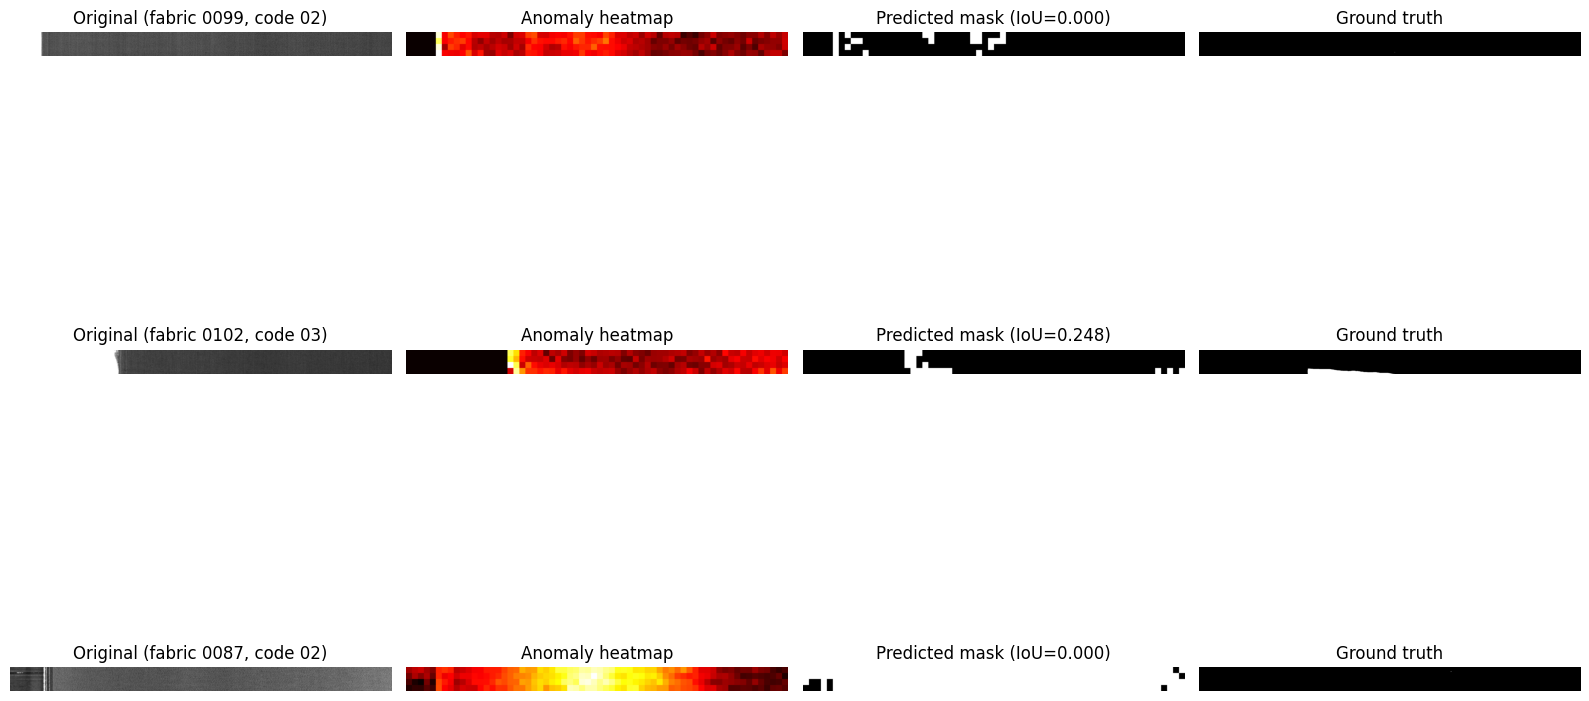

                                                path fabric_id defect_code  \
0  /kaggle/input/datasets/nexuswho/aitex-fabric-i...      0099          02   
1  /kaggle/input/datasets/nexuswho/aitex-fabric-i...      0102          03   
2  /kaggle/input/datasets/nexuswho/aitex-fabric-i...      0087          02   

          model_used       iou  precision    recall  
0  pooled (fallback)  0.000000   0.000000  0.000000  
1  pooled (fallback)  0.248061   0.281101  0.678507  
2  pooled (fallback)  0.000035   0.000035  1.000000  

Mean IoU across 3 demo images: 0.083
Mean precision: 0.094  Mean recall: 0.560


In [4]:

import os, re, glob, json, random
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from skimage.filters import gabor_kernel
from scipy import ndimage as ndi
from scipy.spatial.distance import mahalanobis

random.seed(42)
np.random.seed(42)

INPUT_ROOT = "/kaggle/input"
OUTPUT_ROOT = "/kaggle/working"
os.makedirs(OUTPUT_ROOT, exist_ok=True)

candidate_roots = [d for d in glob.glob(os.path.join(INPUT_ROOT, "*")) if os.path.isdir(d)]
print("Datasets available under /kaggle/input:")
for c in candidate_roots:
    print(" -", c)
DATASET_ROOT = candidate_roots[0] if candidate_roots else None
print("Using DATASET_ROOT =", DATASET_ROOT)

all_images = glob.glob(os.path.join(DATASET_ROOT, "**", "*.*"), recursive=True)
all_images = [f for f in all_images if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"))]
print(f"Total image files found: {len(all_images)}")

def classify_path(p):
    lp = p.lower()
    if "mask" in lp:
        return "mask"
    if "nodefect" in lp or "no_defect" in lp or "good" in lp:
        return "normal"
    if "defect" in lp:
        return "defect"
    return "unknown"

buckets = defaultdict(list)
for f in all_images:
    buckets[classify_path(f)].append(f)
for k, v in buckets.items():
    print(f"{k}: {len(v)} files")


# %% [CELL 2] Index normal/defective images, match masks
def parse_defect_filename(fname):
    stem = os.path.splitext(os.path.basename(fname))[0]
    parts = re.split(r"[_\-]", stem)
    fabric_id = parts[0] if len(parts) > 0 else "unknown"
    defect_code = parts[-1] if len(parts) > 2 else "unknown"
    return fabric_id, defect_code

df_defects = pd.DataFrame(
    [dict(zip(["fabric_id", "defect_code"], parse_defect_filename(f)), path=f)
     for f in buckets["defect"]]
)
df_normal = pd.DataFrame(
    [{"fabric_id": parse_defect_filename(f)[0], "path": f} for f in buckets["normal"]]
)

mask_lookup = {os.path.splitext(os.path.basename(m))[0]: m for m in buckets["mask"]}
def find_mask_for(defect_path):
    stem = os.path.splitext(os.path.basename(defect_path))[0]
    if stem in mask_lookup:
        return mask_lookup[stem]
    for suffix in ["_mask", "-mask", "_gt"]:
        if stem + suffix in mask_lookup:
            return mask_lookup[stem + suffix]
    base = stem.replace("_mask", "").replace("-mask", "")
    return mask_lookup.get(base)

df_defects["mask_path"] = df_defects["path"].apply(find_mask_for)
matched = df_defects.dropna(subset=["mask_path"]).copy()
print(f"Defective images: {len(df_defects)} | Matched masks: {len(matched)}")
print(f"Normal images: {len(df_normal)}")

# Which fabric IDs have BOTH normal images and a mask-matched defective image?
overlap_fabrics = sorted(set(df_normal["fabric_id"]) & set(matched["fabric_id"]))
print(f"Fabric IDs with both normal and defective data: {overlap_fabrics}")


# %% [CELL 3] Preprocessing + texture descriptor functions (same formulas as before)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def load_gray(path):
    return cv2.imread(path, cv2.IMREAD_GRAYSCALE)

def preprocess_image(path):
    im = load_gray(path)
    if im is None:
        return None
    im = clahe.apply(im)
    return cv2.GaussianBlur(im, (3, 3), 0)

PATCH_SIZE = 64
STRIDE = 64  # wider than the original 32 -- 4x fewer patches, still enough for this demo
DEFECT_OVERLAP_THRESH = 0.10

def extract_patches(img, mask=None, patch_size=PATCH_SIZE, stride=STRIDE):
    h, w = img.shape
    out = []
    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            patch = img[y:y + patch_size, x:x + patch_size]
            label = 0
            if mask is not None:
                m_patch = mask[y:y + patch_size, x:x + patch_size]
                label = int((m_patch > 0).mean() >= DEFECT_OVERLAP_THRESH)
            out.append((patch, label, (y, x)))
    return out

GLCM_DISTANCES, GLCM_ANGLES = [1, 3], [0, np.pi/4, np.pi/2, 3*np.pi/4]
GLCM_PROPS = ["contrast", "correlation", "energy", "homogeneity"]

def glcm_features(patch, levels=32):
    q = np.clip((patch.astype(np.float32) / 256.0 * levels).astype(np.uint8), 0, levels - 1)
    glcm = graycomatrix(q, distances=GLCM_DISTANCES, angles=GLCM_ANGLES,
                         levels=levels, symmetric=True, normed=True)
    feats = []
    for prop in GLCM_PROPS:
        vals = graycoprops(glcm, prop)
        feats.extend(vals.mean(axis=1)); feats.extend(vals.std(axis=1))
    return np.array(feats)

LBP_CONFIGS = [(8, 1), (16, 2)]
def lbp_features(patch):
    feats = []
    for P, R in LBP_CONFIGS:
        lbp = local_binary_pattern(patch, P, R, method="uniform")
        n_bins = P + 2
        hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)
        feats.extend(hist)
    return np.array(feats)

GABOR_FREQS, GABOR_THETAS = [0.1, 0.3], [0, np.pi/4, np.pi/2, 3*np.pi/4]
_gabor_kernels = [gabor_kernel(f, theta=t).real for f in GABOR_FREQS for t in GABOR_THETAS]
def gabor_features(patch):
    patch_f = patch.astype(np.float32) / 255.0
    feats = []
    for kernel in _gabor_kernels:
        filtered = ndi.convolve(patch_f, kernel, mode="wrap")
        feats.append(filtered.mean()); feats.append(filtered.var())
    return np.array(feats)

def fft_features(patch):
    f = np.fft.fftshift(np.fft.fft2(patch.astype(np.float32)))
    mag = np.log1p(np.abs(f))
    h, w = mag.shape
    cy, cx = h // 2, w // 2
    yy, xx = np.mgrid[0:h, 0:w]
    r = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)
    feats = []
    for lo, hi in [(0, 4), (4, 10), (10, 20), (20, max(h, w))]:
        band = (r >= lo) & (r < hi)
        feats.append(mag[band].mean() if band.any() else 0.0)
        feats.append(mag[band].std() if band.any() else 0.0)
    return np.array(feats)

def combined_features(patch):
    return np.concatenate([glcm_features(patch), lbp_features(patch),
                            gabor_features(patch), fft_features(patch)])

print("Combined feature vector length:", combined_features(
    load_gray(df_normal["path"].iloc[0])[:PATCH_SIZE, :PATCH_SIZE]).shape)


# %% [CELL 4] Build a POOLED normal-texture model from a handful of normal images
N_NORMAL_IMAGES_FOR_MODEL = 10  # keep small -- this is what makes it fast
normal_sample = df_normal.sample(min(N_NORMAL_IMAGES_FOR_MODEL, len(df_normal)), random_state=42)

pooled_features = []
per_fabric_features = defaultdict(list)  # fabric_id -> list of feature vectors

print(f"Extracting normal-texture features from {len(normal_sample)} images "
      f"(stride={STRIDE}, so this should take under a minute)...")
for _, row in normal_sample.iterrows():
    im = preprocess_image(row["path"])
    if im is None:
        continue
    for patch, _, _ in extract_patches(im, mask=None):
        feat = combined_features(patch)
        pooled_features.append(feat)
        per_fabric_features[row["fabric_id"]].append(feat)

pooled_features = np.array(pooled_features)
print(f"Pooled normal-texture training set: {pooled_features.shape[0]} patches, "
      f"{pooled_features.shape[1]} features each")

def fit_model(X):
    mean_vec = X.mean(axis=0)
    cov = np.cov(X, rowvar=False) + np.eye(X.shape[1]) * 1e-6
    return mean_vec, np.linalg.pinv(cov)

pooled_mean, pooled_inv_cov = fit_model(pooled_features)

per_fabric_models = {}
for fid, feats in per_fabric_features.items():
    feats = np.array(feats)
    if len(feats) > pooled_features.shape[1] + 10:  # need more samples than dimensions
        per_fabric_models[fid] = fit_model(feats)
print(f"Per-fabric models available for: {list(per_fabric_models.keys())}")

# Threshold from pooled normal scores (95th percentile)
pooled_scores = np.array([mahalanobis(f, pooled_mean, pooled_inv_cov) for f in pooled_features])
threshold = np.percentile(pooled_scores, 95)
print(f"Anomaly threshold (95th pct of pooled normal scores): {threshold:.3f}")


# %% [CELL 5] Pick 2-3 real demo images and run the full heatmap -> IoU pipeline
N_DEMO = 3
# Prefer demo images whose fabric ID has its own per-fabric model (more
# faithful to the project's "adaptive per-fabric" design); otherwise we
# fall back to the pooled model for that image.
preferred = matched[matched["fabric_id"].isin(per_fabric_models.keys())]
if len(preferred) >= 1:
    demo_pool = pd.concat([preferred, matched]).drop_duplicates(subset="path")
else:
    demo_pool = matched
demo_rows = demo_pool.sample(min(N_DEMO, len(demo_pool)), random_state=42)

def compute_iou(pred_mask, gt_mask):
    pred_bin, gt_bin = pred_mask > 0, gt_mask > 0
    inter = np.logical_and(pred_bin, gt_bin).sum()
    union = np.logical_or(pred_bin, gt_bin).sum()
    return inter / union if union > 0 else np.nan

def compute_precision_recall(pred_mask, gt_mask):
    pred_bin, gt_bin = pred_mask > 0, gt_mask > 0
    tp = np.logical_and(pred_bin, gt_bin).sum()
    fp = np.logical_and(pred_bin, ~gt_bin).sum()
    fn = np.logical_and(~pred_bin, gt_bin).sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    return precision, recall

def score_image(img_path, fabric_id):
    """Slide over the full image, score each patch, paint a heatmap."""
    im = preprocess_image(img_path)
    h, w = im.shape
    heat = np.zeros((h, w), dtype=np.float32)
    count = np.zeros((h, w), dtype=np.float32)
    mean_vec, inv_cov = per_fabric_models.get(fabric_id, (pooled_mean, pooled_inv_cov))
    for patch, _, (y, x) in extract_patches(im, mask=None):
        s = mahalanobis(combined_features(patch), mean_vec, inv_cov)
        heat[y:y+PATCH_SIZE, x:x+PATCH_SIZE] += s
        count[y:y+PATCH_SIZE, x:x+PATCH_SIZE] += 1
    count[count == 0] = 1
    return heat / count

n_demo = len(demo_rows)
results = []
fig, axes = plt.subplots(n_demo, 4, figsize=(16, 4 * n_demo))
if n_demo == 1:
    axes = axes.reshape(1, -1)

for row_i, (_, row) in enumerate(demo_rows.iterrows()):
    used_model = "per-fabric" if row["fabric_id"] in per_fabric_models else "pooled (fallback)"
    print(f"Scoring demo image {row_i+1}/{n_demo}: {os.path.basename(row['path'])} "
          f"(fabric {row['fabric_id']}, defect {row['defect_code']}, model: {used_model})")

    heat = score_image(row["path"], row["fabric_id"])
    gt_mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
    gt_mask = cv2.resize(gt_mask, (heat.shape[1], heat.shape[0]))
    pred_mask = (heat >= threshold).astype(np.uint8) * 255

    iou = compute_iou(pred_mask, gt_mask)
    prec, rec = compute_precision_recall(pred_mask, gt_mask)
    results.append({
        "path": row["path"], "fabric_id": row["fabric_id"],
        "defect_code": row["defect_code"], "model_used": used_model,
        "iou": iou, "precision": prec, "recall": rec,
    })

    axes[row_i, 0].imshow(load_gray(row["path"]), cmap="gray")
    axes[row_i, 0].set_title(f"Original (fabric {row['fabric_id']}, code {row['defect_code']})")
    axes[row_i, 1].imshow(heat, cmap="hot")
    axes[row_i, 1].set_title("Anomaly heatmap")
    axes[row_i, 2].imshow(pred_mask, cmap="gray")
    axes[row_i, 2].set_title(f"Predicted mask (IoU={iou:.3f})")
    axes[row_i, 3].imshow(gt_mask, cmap="gray")
    axes[row_i, 3].set_title("Ground truth")
    for c in range(4):
        axes[row_i, c].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_ROOT, "worked_example_heatmap_iou.png"), dpi=130)
plt.show()

df_results = pd.DataFrame(results)
print(df_results)
df_results.to_csv(os.path.join(OUTPUT_ROOT, "worked_example_results.csv"), index=False)
print(f"\nMean IoU across {n_demo} demo images: {df_results['iou'].mean():.3f}")
print(f"Mean precision: {df_results['precision'].mean():.3f}  "
      f"Mean recall: {df_results['recall'].mean():.3f}")